# Forward and Backpropagation using TensorFlow/Keras
Ready to run in Google Colab.

In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import pandas as pd
(x_train,y_train),(x_test,y_test)=tf.keras.datasets.mnist.load_data()
x_train=x_train.reshape(-1,784)/255.0
x_test=x_test.reshape(-1,784)/255.0
def create_model(lr):
    m=Sequential([Dense(128,activation='relu',input_shape=(784,)),
                  Dense(64,activation='relu'),
                  Dense(10,activation='softmax')])
    m.compile(optimizer=Adam(learning_rate=lr),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
    return m


C:\Users\Pranav\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


   Learning Rate  Accuracy
0          0.100    0.7776
1          0.010    0.9635
2          0.001    0.9728


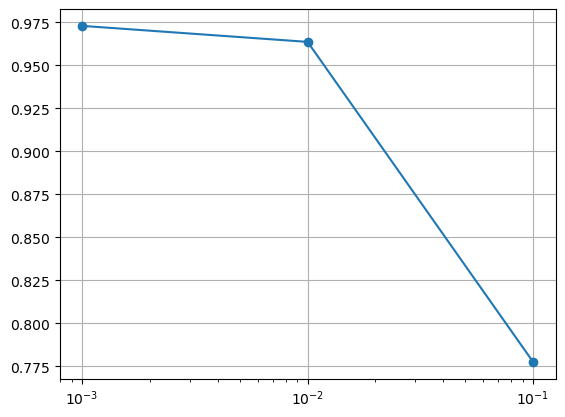

In [2]:
learning_rates=[0.1,0.01,0.001]
results=[]
for lr in learning_rates:
    model=create_model(lr)
    model.fit(x_train,y_train,epochs=5,batch_size=128,verbose=0)
    loss,acc=model.evaluate(x_test,y_test,verbose=0)
    results.append([lr,acc])
df=pd.DataFrame(results,columns=['Learning Rate','Accuracy'])
print(df)
plt.plot(df['Learning Rate'],df['Accuracy'],marker='o')
plt.xscale('log'); plt.grid(); plt.show()


C:\Users\Pranav\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


   Epochs  Accuracy
0       5    0.9712
1      10    0.9747
2      20    0.9759


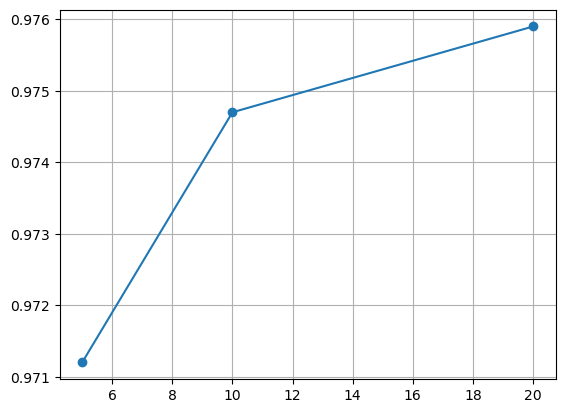

C:\Users\Pranav\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.8968 - loss: 0.3621 - val_accuracy: 0.9509 - val_loss: 0.1742
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9560 - loss: 0.1492 - val_accuracy: 0.9590 - val_loss: 0.1380
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9683 - loss: 0.1049 - val_accuracy: 0.9663 - val_loss: 0.1144
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9765 - loss: 0.0799 - val_accuracy: 0.9656 - val_loss: 0.1100
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9812 - loss: 0.0632 - val_accuracy: 0.9693 - val_loss: 0.1029
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9847 - loss: 0.0525 - val_accuracy: 0.9710 - val_loss: 0.0959
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9880 - loss: 0.0409 - val_accuracy: 0.9722 - val_loss: 0.0947
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.9905 - loss: 0.0330 - val_accu

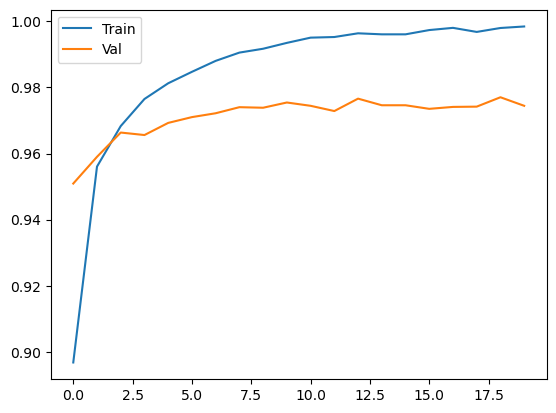

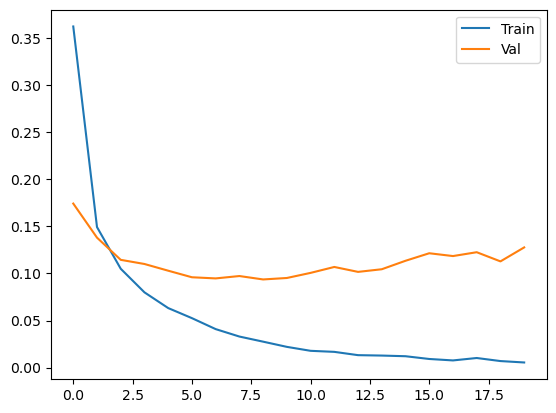

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9751 - loss: 0.1047 
[0.10472533851861954, 0.9750999808311462]


In [3]:
epochs_list=[5,10,20]
res=[]
for ep in epochs_list:
    model=create_model(0.001)
    h=model.fit(x_train,y_train,validation_split=0.2,epochs=ep,batch_size=128,verbose=0)
    loss,acc=model.evaluate(x_test,y_test,verbose=0)
    res.append([ep,acc])
edf=pd.DataFrame(res,columns=['Epochs','Accuracy'])
print(edf)
plt.plot(edf['Epochs'],edf['Accuracy'],marker='o')
plt.grid(); plt.show()

model=create_model(0.001)
history=model.fit(x_train,y_train,validation_split=0.2,epochs=20,batch_size=128)
plt.plot(history.history['accuracy']); plt.plot(history.history['val_accuracy']); plt.legend(['Train','Val']); plt.show()
plt.plot(history.history['loss']); plt.plot(history.history['val_loss']); plt.legend(['Train','Val']); plt.show()
print(model.evaluate(x_test,y_test))
